# Random Forest Model Evaluation
**Binary Classification: Seizure vs Non-Seizure**

This notebook evaluates the Random Forest model using the same medical metrics as the baseline (Logistic Regression). 
It also saves the key performance indicators to a JSON file for easy comparison.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc
)

# Set style
sns.set(style="whitegrid")

## 1. Load Predictions
Loading the test set predictions generated by `src/training/train_random_forest.py`.

In [2]:
# Check if files exist
output_dir = "../outputs"
required_files = ["rf_y_test_true.npy", "rf_y_test_pred.npy", "rf_y_test_prob.npy"]

for f in required_files:
    path = os.path.join(output_dir, f)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}. Run train_random_forest.py first.")

y_true = np.load(os.path.join(output_dir, "rf_y_test_true.npy"))
y_pred = np.load(os.path.join(output_dir, "rf_y_test_pred.npy"))
y_prob = np.load(os.path.join(output_dir, "rf_y_test_prob.npy"))

print(f"Loaded {len(y_true)} test samples.")

Loaded 13200 test samples.


## 2. Medical Metrics Calculation

In [3]:
# Calculate basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Specific Rates
specificity = tn / (tn + fp)
fp_rate = fp / (fp + tn)
fn_rate = fn / (fn + tp)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9835
Precision: 0.9347
Recall (Sensitivity): 0.9864
Specificity: 0.9828
F1-Score: 0.9598


## 3. Visualization

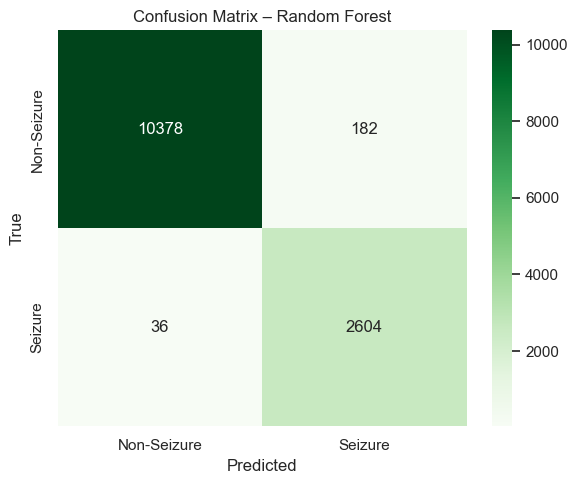

In [4]:
# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Seizure", "Seizure"],
    yticklabels=["Non-Seizure", "Seizure"]
)
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

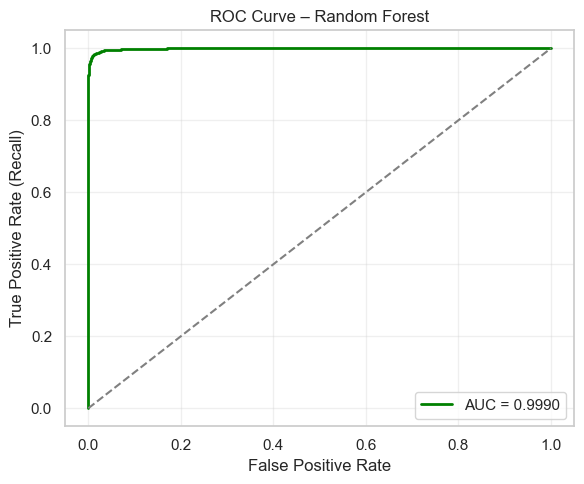

In [5]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color='green', lw=2)
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Save Metrics to JSON
Saving the calculated metrics to `metrics/RF_metrics.json` for later comparison with other models.

In [6]:
metrics_data = {
    "model": "Random Forest",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "specificity": float(specificity),
    "f1_score": float(f1),
    "auc": float(roc_auc),
    "confusion_matrix": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }
}

# Establish directory
metrics_dir = "../metrics"
if not os.path.exists(metrics_dir):
    os.makedirs(metrics_dir)

# Save to file
file_path = os.path.join(metrics_dir, "RF_metrics.json")
with open(file_path, "w") as f:
    json.dump(metrics_data, f, indent=4)

print(f"Metrics saved to {file_path}")

Metrics saved to ../metrics/RF_metrics.json
